In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex03_gaussian_heatmap_with_mse_tv_losses', 'pitch_calibration_dataset': {'img_folder': 'data/calibration', 'width': 640, 'height': 360, 'centered': False, 'keypoint_only': False, 'selected_idxs': [0, 3, 4, 5]}, 'pitch_calibration_datamodule': {'batch_size': 8, 'num_workers': 8, 'persistent_workers': True}, 'gaussian_heatmap_model': 'wandb_logs/ISC-Football/gwqhfk3g/checkpoints/epoch=2-step=192.ckpt', 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'width': 3840, 'height': 2160, 'n_crops': 16, 'crop_width': 512, 'crop_height': 512, 'n_limit': 4}, 'spiideo_datamodule': {'batch_size': 4, 'num_workers': 8, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [2]:
import gc
import cv2
import torch
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

import numpy as np
import matplotlib.pyplot as plt
import random
import requests
from PIL import Image

from dataobjects.pitch import Pitch
from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.calibration.calibration import CalibrationDataModule, CalibrationDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs
from datamodules.spiideo.gaussian import Spiideo2DGaussianMaskDataModule, Spiideo2DGaussianMaskDatasetArgs
from models.base.unet_heatmap import UNetHeatmap

from ultralytics import YOLO
from transformers import DetrImageProcessor, DetrForObjectDetection
from transformers import SamModel, SamProcessor
from sklearn.cluster import MiniBatchKMeans

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
spiideo_args = SpiideoDatasetArgs(**config['spiideo_dataset'])
spiideo_data_module = SpiideoWithMetadataDataModule(
    SpiideoDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)

ds = spiideo_data_module.dataset('mini')
print(f'Dataset with {len(ds)} images.')

Dataset with 4 images.


In [4]:
width, height = config['spiideo_dataset']['width'], config['spiideo_dataset']['height']
img, metadata, annotations, *_ = ds[0]
metadata.model_dump()

{'id': 0,
 'file_name': '000000.jpg',
 'width': 3840,
 'height': 2160,
 'camera_matrix': array([[   -0.46929,     0.86437,     0.18063,     -31.647],
        [    0.38043,    0.013311,     0.92471,      6.2207],
        [   -0.79689,    -0.50268,     0.33508,     -46.556]]),
 'dist_poly': array([   0.036689,    -0.18117,     0.26818,    0.036817,    -0.40782,     0.25091,    -0.11877,     0.76886, -0.00070755]),
 'undist_poly': array([ 3.7321e-12, -1.1132e-11,  1.2713e-11, -6.6551e-12,      1.0398,    -0.50454,     0.23419,      1.3027,  0.00089824])}

## Gaussian mask

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_24001/2475762401.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


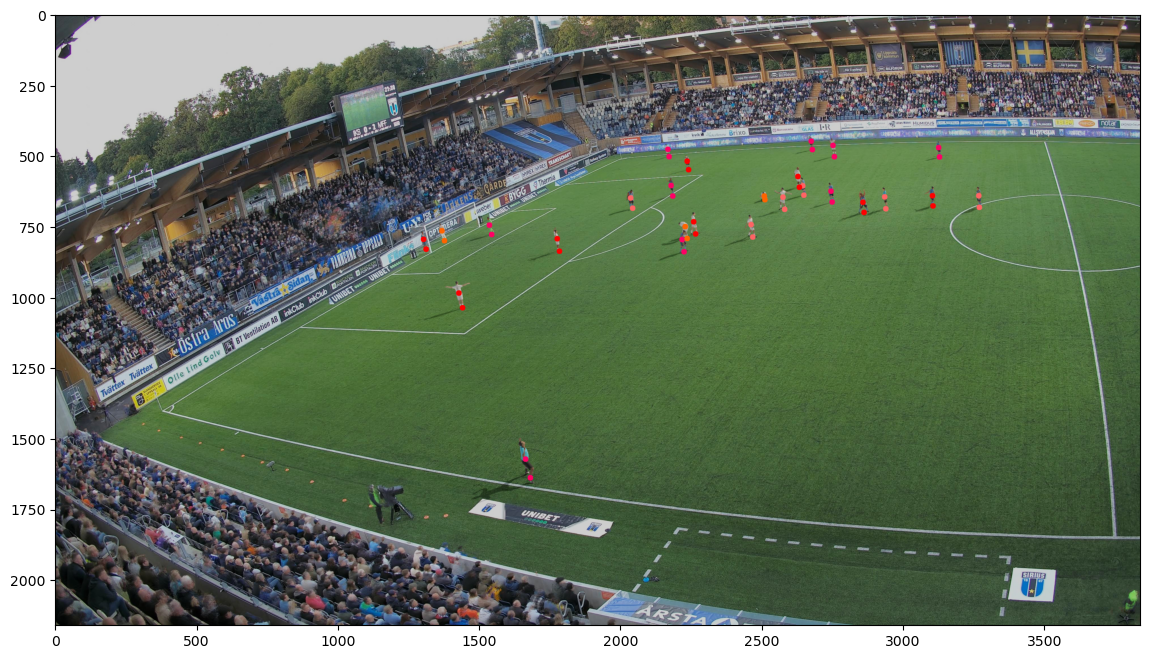

In [5]:
img, metadata, annotations, *_ = ds[0]
annotated_img = (img.copy() * 255).astype('uint8')
colours = [(255, 0, 0), (255, 100, 0), (255, 0, 100), (255, 100, 100)]

centers = []
sigmas = []

for annotation in annotations:
    colour = colours[random.randint(0, 3)]
    kps = []
    for x, y, z in annotation.keypoints.astype('int'):
        x0, y0 = int(x / z * width / metadata.width), int(y / z * height / metadata.height)
        annotated_img = cv2.circle(annotated_img, (x0, y0), height // 200, colour, -1)
        kps.append((x0, y0))

    (x0, y0), (x1, y1) = kps
    if y0 > y1:
        (x0, y0), (x1, y1) = kps[::-1]

    centers.append((x0, y0))
    sigmas.append((abs(y0 - y1) / 4, abs(y0 - y1) / 2))

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(annotated_img)
fig.show()

In [6]:
def generate_gmm_heatmap(shape, centers, sigmas):
    """
    Generates a 2D Gaussian Mixture Map.
    
    Args:
        shape: Tuple (height, width) for the output map.
        centers: List of tuples [(x1, y1), (x2, y2), ...]
        sigmas: List of sigmas. Can be a single value [s1, s2] 
                or tuples for anisotropic shapes [(sx1, sy1), ...].
    """
    h, w = shape
    # Create coordinate grids
    y_grid, x_grid = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    
    # Initialize an empty heatmap
    heatmap = np.zeros((h, w), dtype=np.float32)
    
    for (cx, cy), s in zip(centers, sigmas):
        # Handle both circular (scalar) and elliptical (tuple) sigmas
        sx, sy = (s, s) if isinstance(s, (int, float)) else s
        
        # Calculate the 2D Gaussian exponent
        exponent = -((x_grid - cx)**2 / (2 * sx**2) + (y_grid - cy)**2 / (2 * sy**2))
        
        # Add the Gaussian to the mixture
        heatmap += np.exp(exponent)
        
    return heatmap

heatmap = generate_gmm_heatmap((height, width), centers, sigmas)
print(heatmap.max())

heatmap *= 255 / heatmap.max()
heatmap = heatmap.astype('uint8')
heatmap = np.stack([heatmap] * 3, axis=2)
heatmap.shape

1.083544


(2160, 3840, 3)

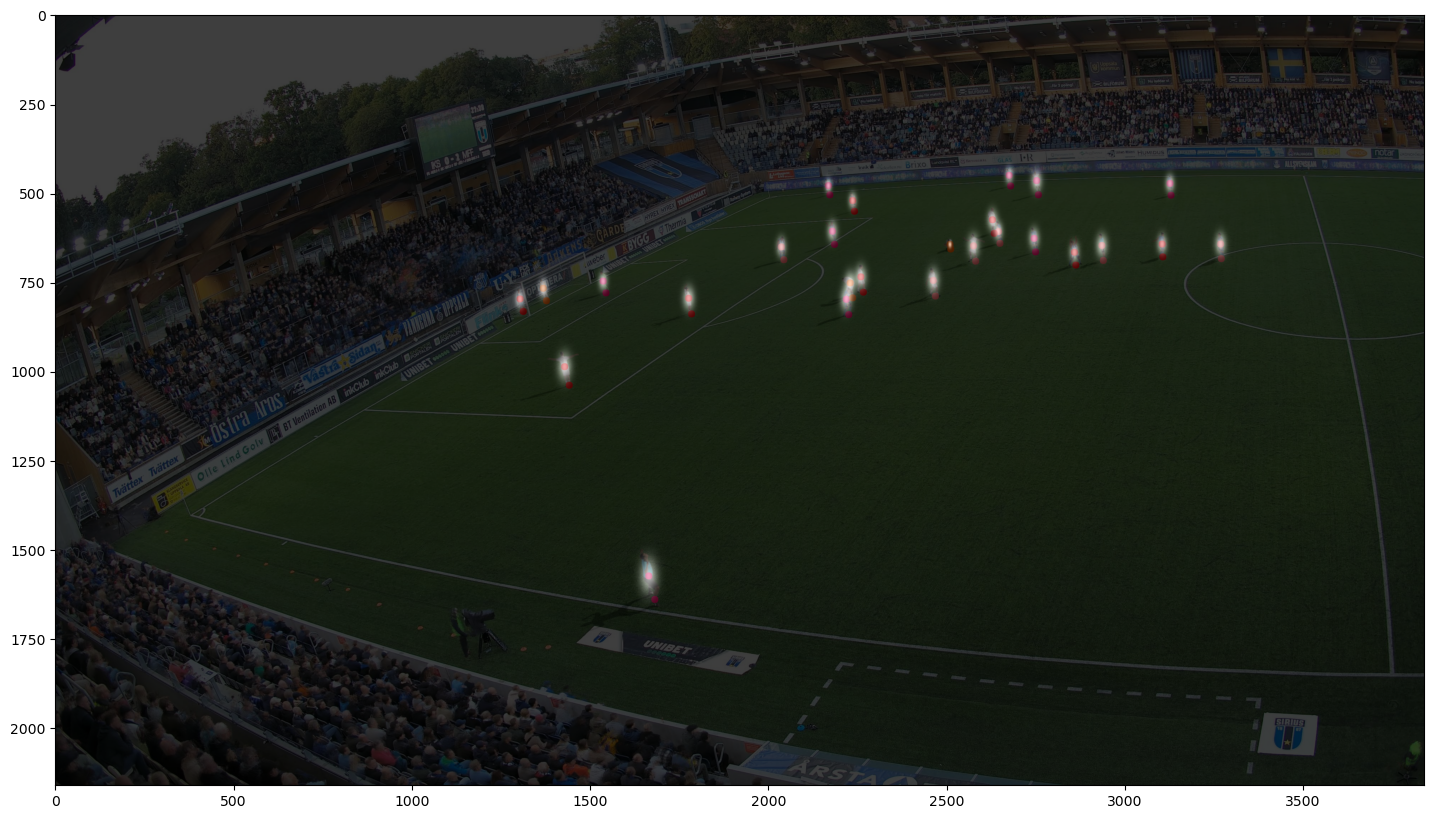

In [7]:
img_heatmap = cv2.addWeighted(annotated_img, 0.3, heatmap, 0.7, 0.0)
plt.figure(figsize=(20, 10))
plt.imshow(img_heatmap, cmap='gray')
plt.show()

In [8]:
spiideo_gaussian_data_module = Spiideo2DGaussianMaskDataModule(
    Spiideo2DGaussianMaskDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule']),
    debug=True
)

In [9]:
gaussian_ds = spiideo_gaussian_data_module.dataset('mini')
gaussian_dataloader = DataLoader(gaussian_ds, batch_size=16)
gaussian_dataloader

In [10]:
config['gaussian_heatmap_model'] = \
    "wandb_logs/ISC-Football/43w92qhx/checkpoints/epoch=21-step=352.ckpt"
    # "wandb_logs/ISC-Football/t1oa8zkk/checkpoints/epoch=23-step=384.ckpt"
    # "wandb_logs/ISC-Football/qg1fznbp/checkpoints/epoch=31-step=512.ckpt"
    # "wandb_logs/ISC-Football/tqm1ydr7/checkpoints/epoch=6-step=112.ckpt"
    # [TODO]: Rerun the model again.

In [11]:
DEVICE = 'mps'
gaussian_model = UNetHeatmap \
    .load_from_checkpoint(config['gaussian_heatmap_model'], weights_only=True) \
    .to(DEVICE) \
    .float()
    # .to(torch.float8_e4m3fn)            # Precision cut

gaussian_model.eval()

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0
Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main


UNetHeatmap(
  (loss_fns): ModuleDict(
    (mse): MSELoss()
    (tv): TotalVariationLoss(
      (tv_loss): TotalVariation()
    )
  )
  (unet): UNet(
    (non_linearity): ReLU(inplace=True)
    (first_convs): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): ReLU(inplace=True)
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): ReLU(inplace=True)
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    )
    (last_conv): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
    (contraction1): ContractionBlock(
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (conv_block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)

In [12]:
gaussian_dataloader_iter = iter(gaussian_dataloader)
next(gaussian_dataloader_iter)
next(gaussian_dataloader_iter)
img, mask = next(gaussian_dataloader_iter)
img = img.to(DEVICE)

print('img.shape  = ', img.shape)
print('mask.shape = ', mask.shape)

# img = img.unsqueeze(0)
# mask = mask.unsqueeze(0)
heatmap = gaussian_model(img)

print('Model output:')
print('img.shape  = ', img.shape)
print('heatmap.shape = ', heatmap.shape)
print('mask.shape = ', mask.shape)

img.shape  =  torch.Size([16, 1, 512, 512])
mask.shape =  torch.Size([16, 1, 512, 512])
Model output:
img.shape  =  torch.Size([16, 1, 512, 512])
heatmap.shape =  torch.Size([16, 1, 512, 512])
mask.shape =  torch.Size([16, 1, 512, 512])


Output for display:
img.shape  =  torch.Size([2058, 2058, 3])
heatmap.shape =  torch.Size([2058, 2058, 3])
mask.shape =  torch.Size([2058, 2058, 3])


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_24001/1380076439.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


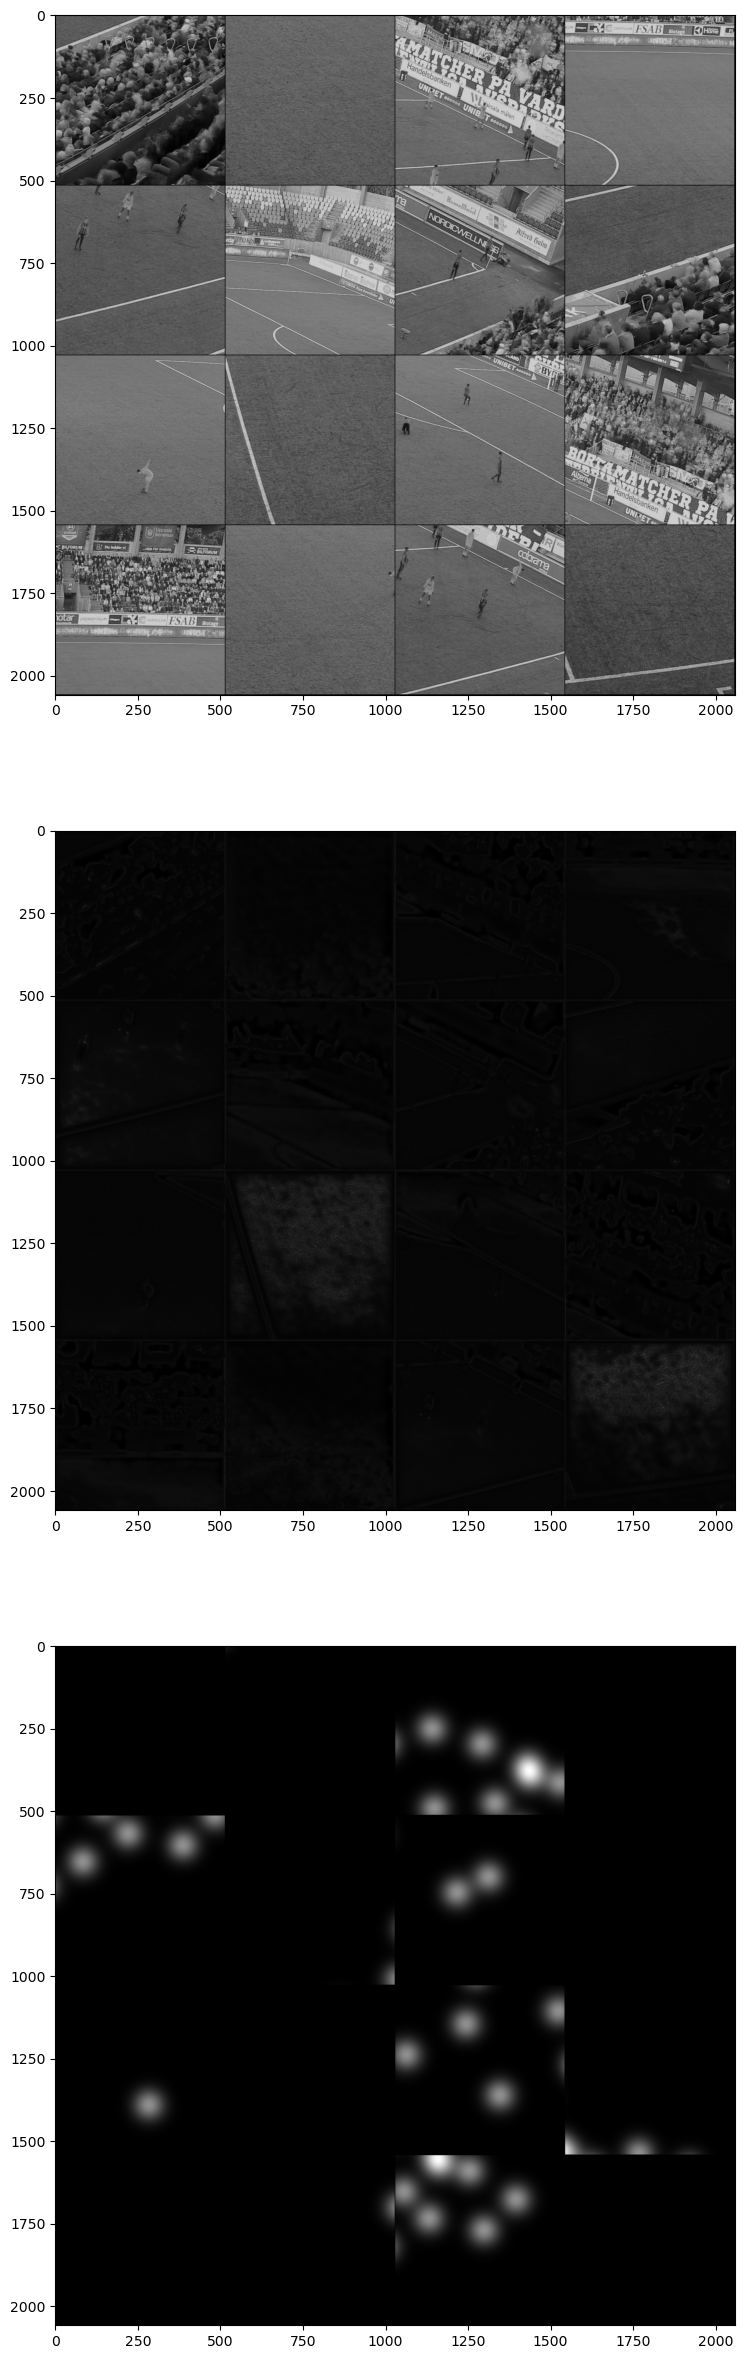

In [13]:
def gridify(img):
    return make_grid(img, nrow=4).permute((1, 2, 0)).cpu()

img_ = gridify(img)
heatmap_ = gridify(heatmap)
mask_ = gridify(mask)

print('Output for display:')
print('img.shape  = ', img_.shape)
print('heatmap.shape = ', heatmap_.shape)
print('mask.shape = ', mask_.shape)

fig, ax = plt.subplots(nrows=3, figsize=(40,30))
ax[0].imshow(img_, cmap='gray')
ax[1].imshow(heatmap_, cmap='gray')
ax[2].imshow(mask_, cmap='gray')
fig.show()

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_24001/960177970.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clipped_heatmap_ = torch.tensor(heatmap_)
/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_24001/960177970.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


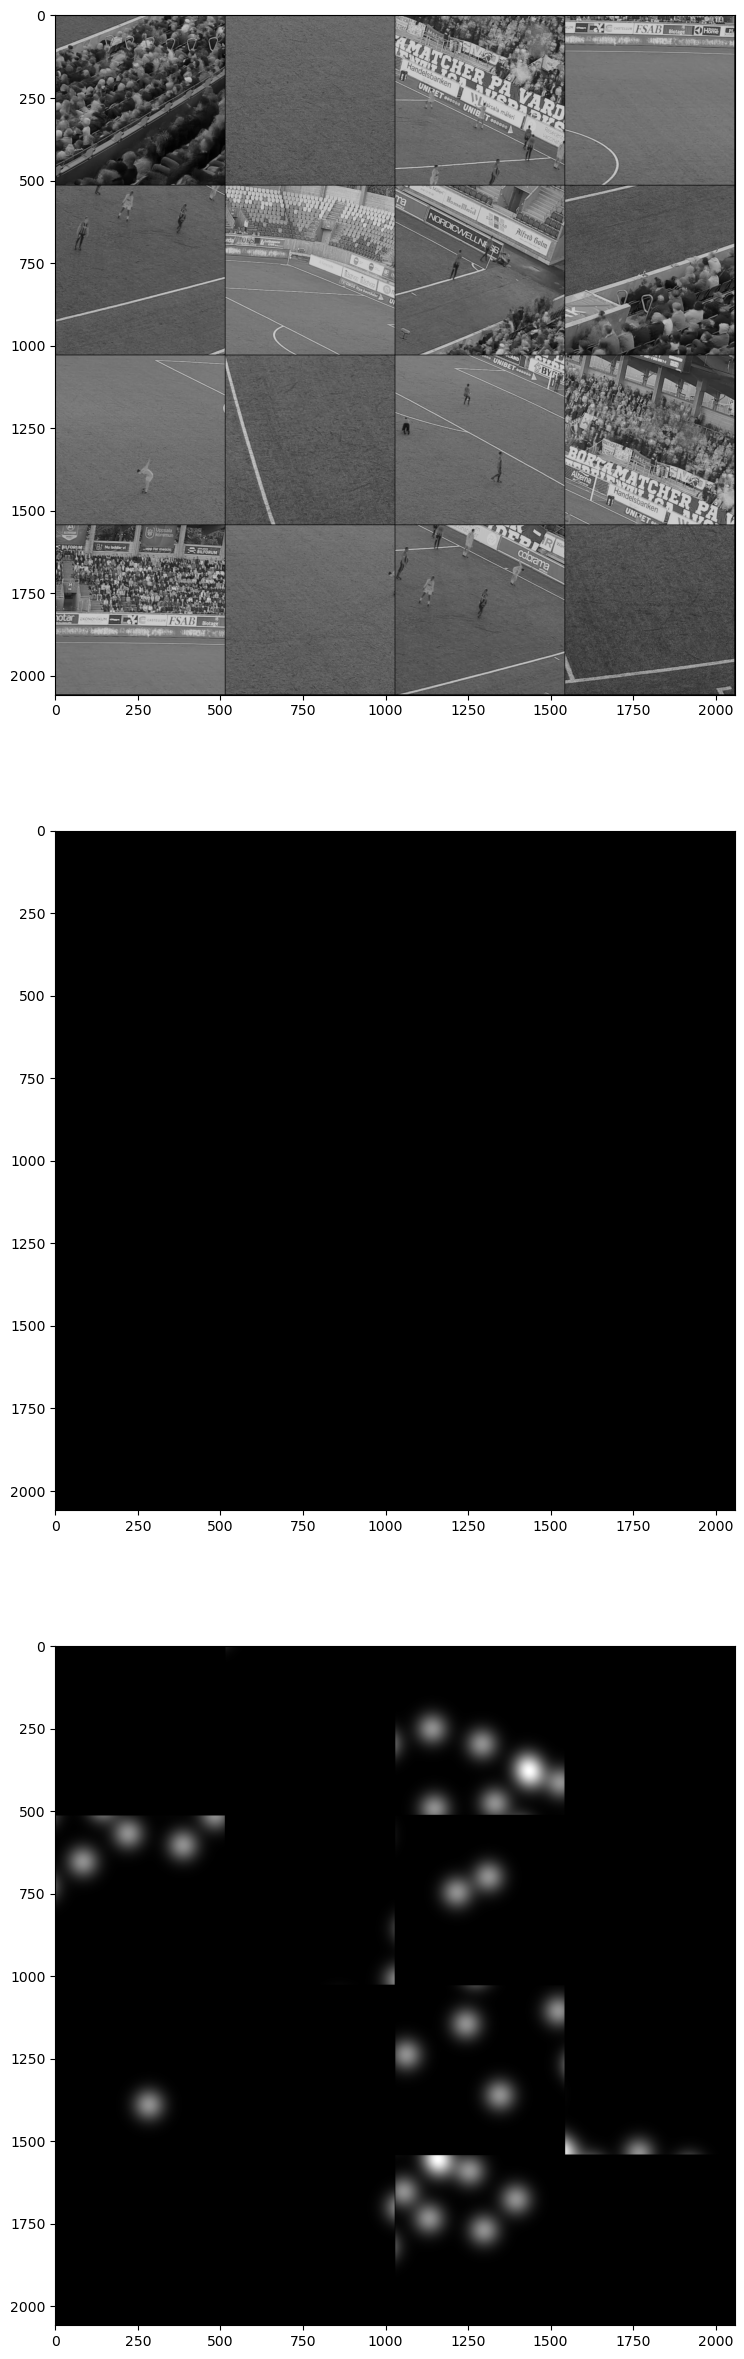

In [14]:
THRESHOLD = 0.80
clipped_heatmap_ = torch.tensor(heatmap_)
clipped_heatmap_[clipped_heatmap_ < THRESHOLD] = 0

fig, ax = plt.subplots(nrows=3, figsize=(40,30))
ax[0].imshow(img_, cmap='gray')
ax[1].imshow(clipped_heatmap_, cmap='gray')
ax[2].imshow(mask_, cmap='gray')
fig.show()

### GMM

In [15]:
%load_ext autoreload
%autoreload 2
from pipelines.player_detection.location_detector import LocationDetector

In [16]:
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_24001/1916968286.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  heatmap_one = torch.tensor(heatmap_one)


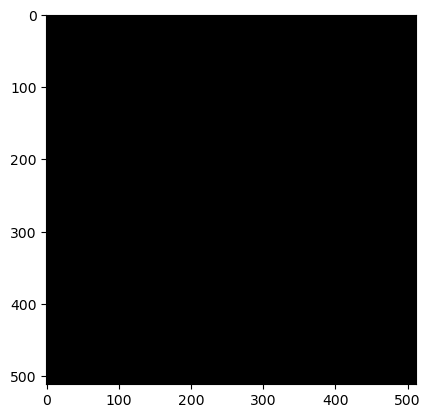

In [17]:
BATCH_IDX = 0
THRESHOLD = 0.60
heatmap_one = heatmap[BATCH_IDX].detach().cpu().view(512, 512)
heatmap_one[heatmap_one < THRESHOLD] = 0
# heatmap_one = MinMaxScaler().fit_transform(heatmap_one)
heatmap_one = torch.tensor(heatmap_one)

plt.imshow(heatmap_one, cmap='gray')
plt.show()

In [18]:
heatmap_one_idxs = torch.nonzero(heatmap_one, as_tuple=False)
heatmap_one_idxs.shape
# heatmap_one_idxs

torch.Size([0, 2])

In [19]:
ks = range(2, 21, 1)
em_bounds = []

for k in ks:
    gmm = GaussianMixture(n_components=k).fit(heatmap_one_idxs)
    em_bounds.append(gmm.lower_bound_)
    # aics.append(gmm.aic(heatmap_one_idxs))
    # bics.append(gmm.bic(heatmap_one_idxs))

ks = np.array(ks)
em_bounds = np.array(em_bounds)
em_bounds = (em_bounds - em_bounds.max()) / (em_bounds.min() - em_bounds.max())

plt.plot(ks, em_bounds, label='EM')
plt.plot(ks[:-2], np.diff(np.diff(em_bounds)), label='Diff EM')
plt.legend()
plt.show()


ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 2 is required by GaussianMixture.

In [ ]:
best_k = 2 + ks[np.argmax(-np.diff(em_bounds))]
best_k
# best_k = 10

np.int64(4)

Initialization 0
Initialization converged. time lapse 0.01715s	 lower bound -9.99046.


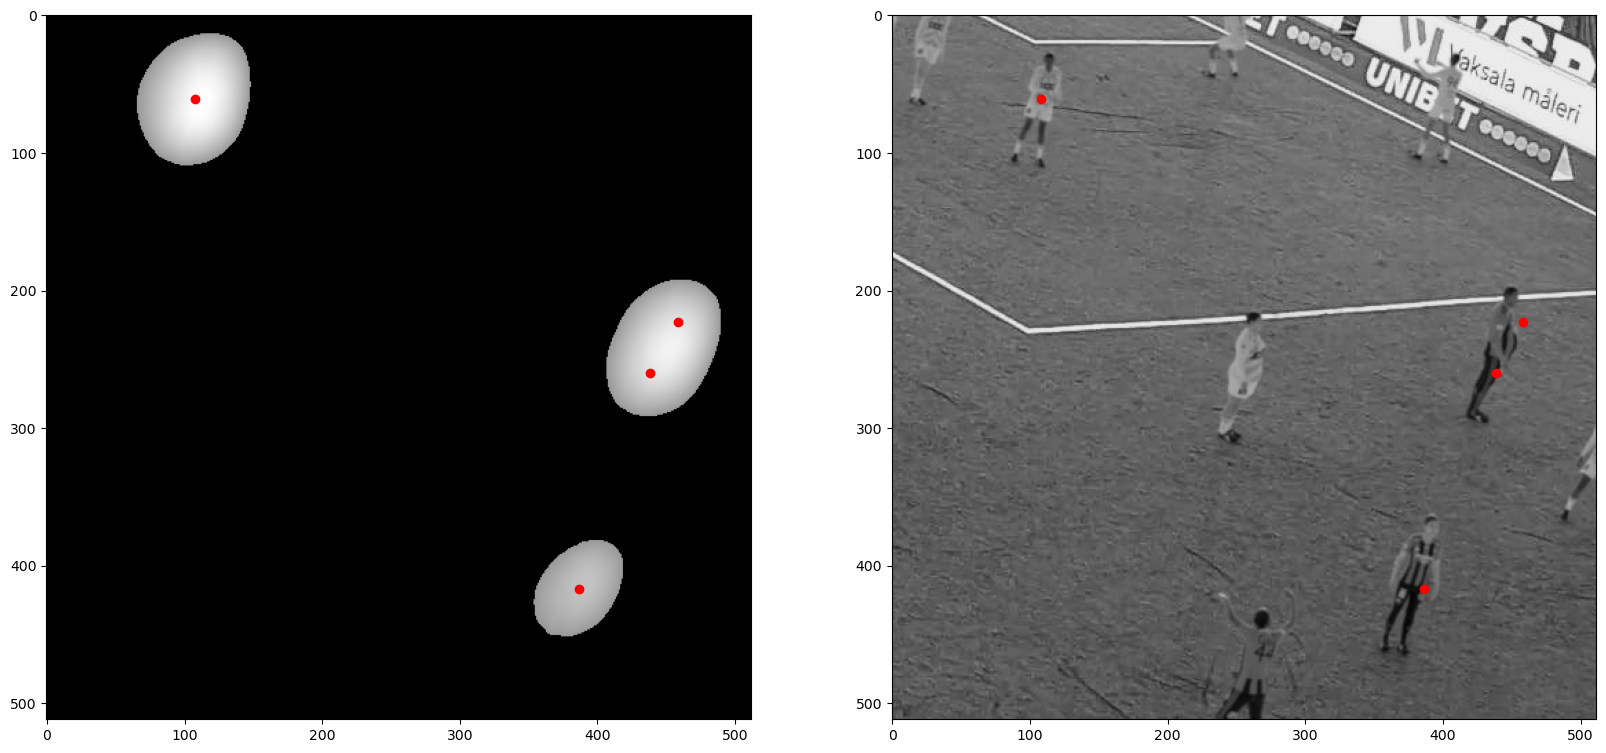

In [ ]:
gmm = GaussianMixture(n_components=best_k, covariance_type='spherical', verbose=2).fit(heatmap_one_idxs)
Ys, Xs = gmm.means_.T

fig, axes = plt.subplots(ncols=2, figsize=(20, 10))

axes[0].imshow(heatmap_one, cmap='gray')
axes[0].scatter(Xs, Ys, c='red')

axes[1].imshow(img[BATCH_IDX][0].detach().cpu(), cmap='gray')
axes[1].scatter(Xs, Ys, c='red')

plt.show()

Initialization 0
  Iteration 10	 time lapse 0.19086s	 ll change 33.23331
  Iteration 20	 time lapse 0.15407s	 ll change 24.78031
  Iteration 30	 time lapse 0.12370s	 ll change 76.40189
  Iteration 40	 time lapse 0.12440s	 ll change 10.11731
  Iteration 50	 time lapse 0.12955s	 ll change 18.85824
  Iteration 60	 time lapse 0.12914s	 ll change 18.00424
  Iteration 70	 time lapse 0.13661s	 ll change 18.44318
  Iteration 80	 time lapse 0.12726s	 ll change 17.85004
  Iteration 90	 time lapse 0.12501s	 ll change 13.96115
  Iteration 100	 time lapse 0.13092s	 ll change 8.92056
Initialization did not converge. time lapse 1.37164s	 lower bound -130677.36189.
Initialization 1
  Iteration 10	 time lapse 0.14285s	 ll change 32.74220
  Iteration 20	 time lapse 0.14539s	 ll change 29.77320
  Iteration 30	 time lapse 0.12030s	 ll change 38.69332
  Iteration 40	 time lapse 0.12539s	 ll change 24.74838
  Iteration 50	 time lapse 0.12106s	 ll change 19.06932
  Iteration 60	 time lapse 0.14265s	 ll chang

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


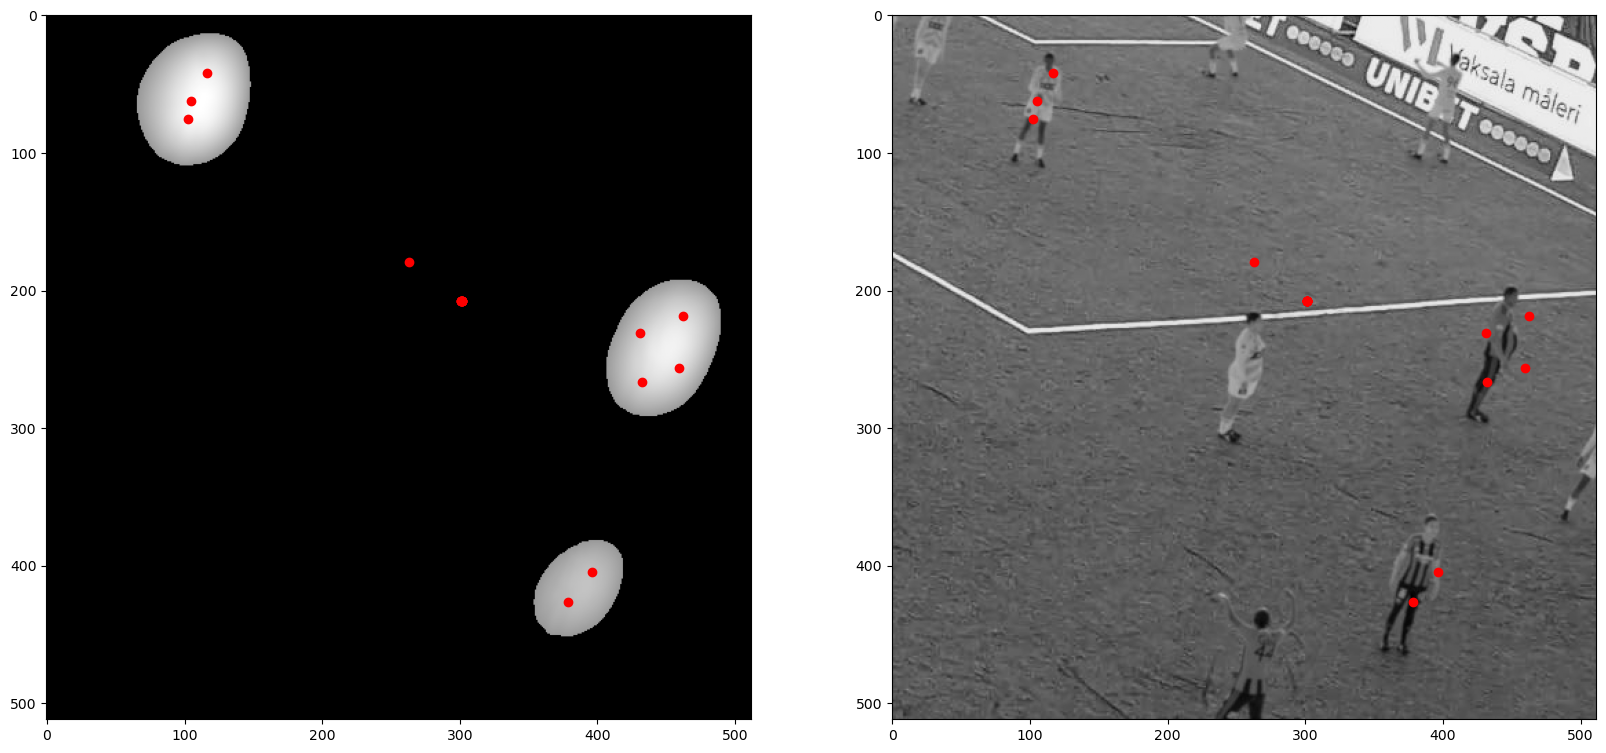

In [ ]:
bgmm = BayesianGaussianMixture(
    n_components=20, covariance_type='spherical', verbose=2,
    max_iter=100,
    tol=1e-3,
    n_init=5, 
    weight_concentration_prior=1e-1
).fit(heatmap_one_idxs)
Ys, Xs = bgmm.means_.T

fig, axes = plt.subplots(ncols=2, figsize=(20, 10))

axes[0].imshow(heatmap_one, cmap='gray')
axes[0].scatter(Xs, Ys, c='red')

axes[1].imshow(img[BATCH_IDX][0].detach().cpu(), cmap='gray')
axes[1].scatter(Xs, Ys, c='red')

plt.show()

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
Initialization did not converge.


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


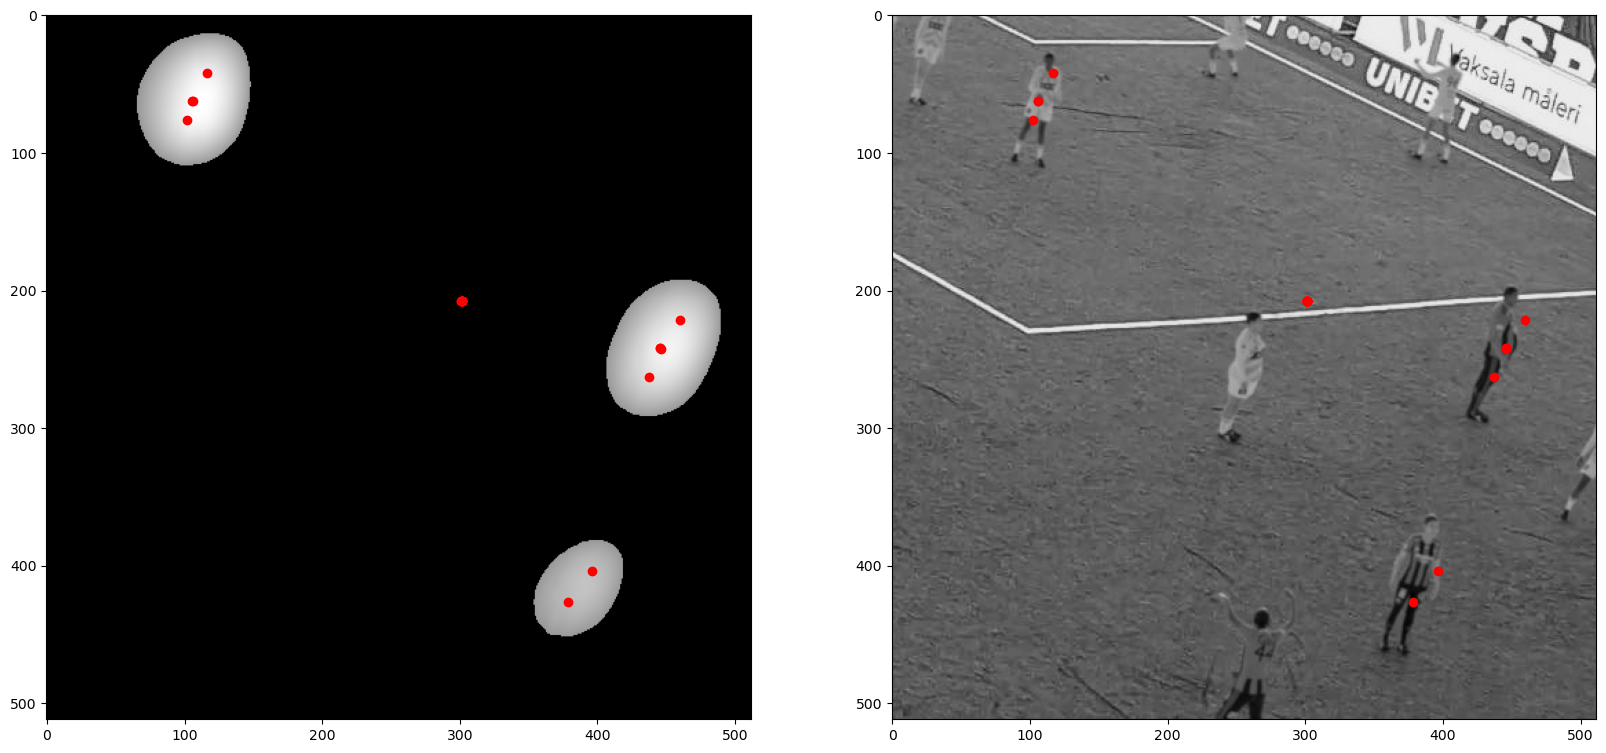

In [ ]:
Ys, Xs = LocationDetector(max_components=20) \
    .forward(heatmap_one.unsqueeze(0).unsqueeze(0)) \
    .T

fig, axes = plt.subplots(ncols=2, figsize=(20, 10))

axes[0].imshow(heatmap_one, cmap='gray')
axes[0].scatter(Xs, Ys, c='red')

axes[1].imshow(img[BATCH_IDX][0].detach().cpu(), cmap='gray')
axes[1].scatter(Xs, Ys, c='red')

plt.show()

In [ ]:
raise NotImplementedError()

NotImplementedError: 

## Putting things together

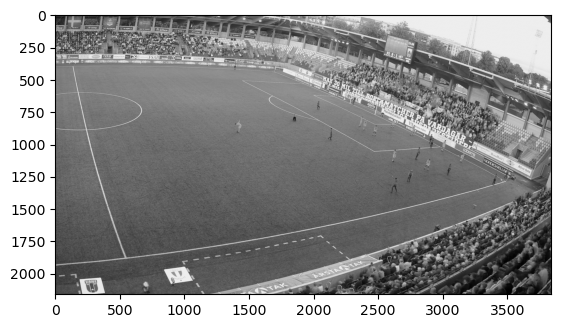

In [ ]:
img, *_ = ds[2]
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img = torch.tensor(img).unsqueeze(0).unsqueeze(0).to(DEVICE)

plt.imshow(img[0][0].detach().cpu(), cmap='gray')
plt.show()

In [ ]:
%load_ext autoreload
%autoreload 2

from pipelines.player_detection.crop_then_stitch import CropThenStitch
from pipelines.player_detection.crop_then_stack import CropThenStack

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
mask_all = CropThenStitch(gaussian_model, (480, 480))(img)
mask_all

tensor([[[[0.0315, 0.0231, 0.0224,  ..., 0.0403, 0.0359, 0.0457],
          [0.0234, 0.0115, 0.0102,  ..., 0.0180, 0.0185, 0.0310],
          [0.0338, 0.0119, 0.0189,  ..., 0.0181, 0.0251, 0.0347],
          ...,
          [0.5291, 0.1865, 0.2492,  ..., 0.0115, 0.0108, 0.0170],
          [0.3773, 0.1804, 0.1987,  ..., 0.0118, 0.0116, 0.0192],
          [0.6419, 0.5407, 0.4822,  ..., 0.0246, 0.0206, 0.0317]]]], device='mps:0')

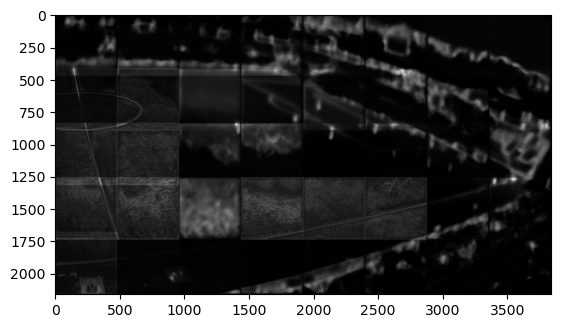

In [ ]:
plt.imshow(mask_all[0][0].cpu(), cmap='gray')
plt.show()

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_10163/2261164470.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 / (1 + np.exp(-beta * x))


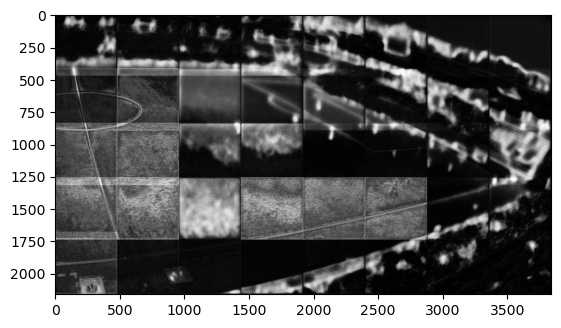

In [ ]:
def _sigmoid(x, beta=1):
    return 1 / (1 + np.exp(-beta * x))

plt.imshow(_sigmoid(mask_all[0][0].cpu(), 3), cmap='gray')
plt.show()

In [ ]:
THRESHOLD = 0.60
clipped_mask_all = torch.tensor(mask_all)
clipped_mask_all[clipped_mask_all < THRESHOLD] = 0

/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_10163/3429349520.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clipped_mask_all = torch.tensor(mask_all)


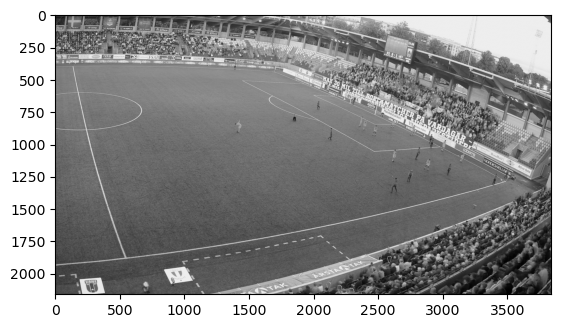

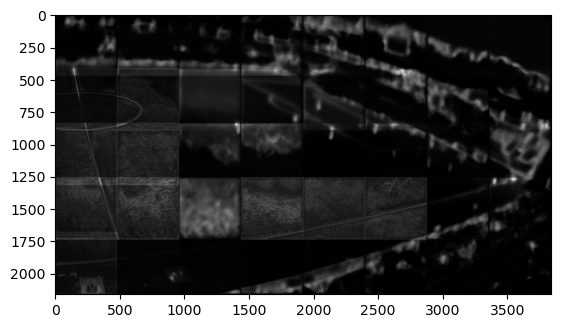

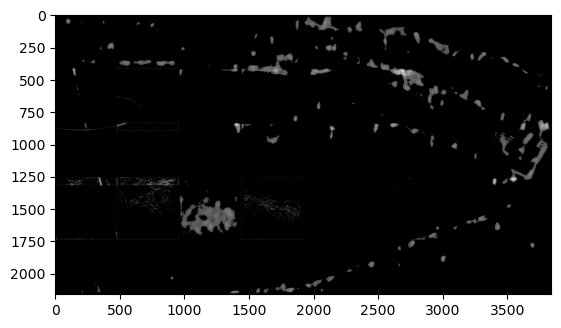

In [ ]:
plt.imshow(img[0][0].detach().cpu(), cmap='gray')
plt.show()

plt.imshow(mask_all[0][0].cpu(), cmap='gray')
plt.show()

plt.imshow(clipped_mask_all[0][0].cpu(), cmap='gray')
plt.show()

In [ ]:
keypoints = LocationDetector()(clipped_mask_all)
keypoints

/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


tensor([[ 366.7505,  596.0536],
        [ 586.4447, 2960.3098],
        [ 122.3043, 2083.9240],
        [1565.6111, 1288.1565],
        [ 251.5551, 2583.4169],
        [1790.6903, 2789.1403],
        [1368.2313,  418.0982],
        [ 442.9684, 2047.5759],
        [2083.8933, 1856.1938],
        [1161.3370, 3590.5428],
        [ 826.6894, 2049.8566],
        [ 947.1764, 3686.7772],
        [ 494.6983, 2742.1737],
        [ 914.1723, 1557.1655],
        [1570.4247, 1103.8028],
        [1348.6804,  801.3517],
        [1481.8742, 1691.9400],
        [1612.3656, 3375.0229],
        [ 390.2502, 3532.0598],
        [ 385.2810, 1651.1632]], dtype=torch.float64)

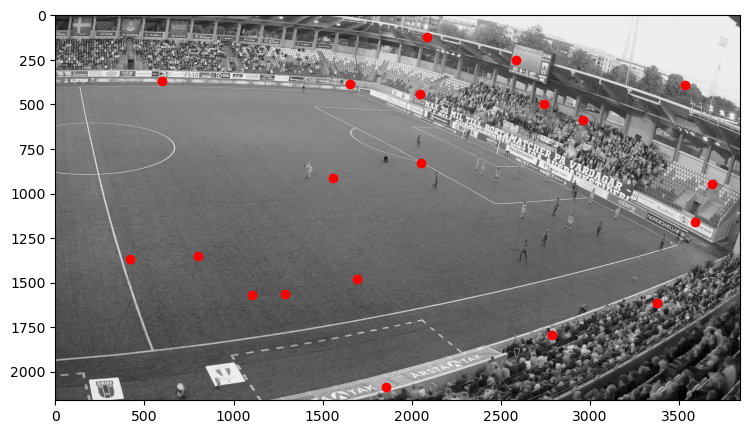

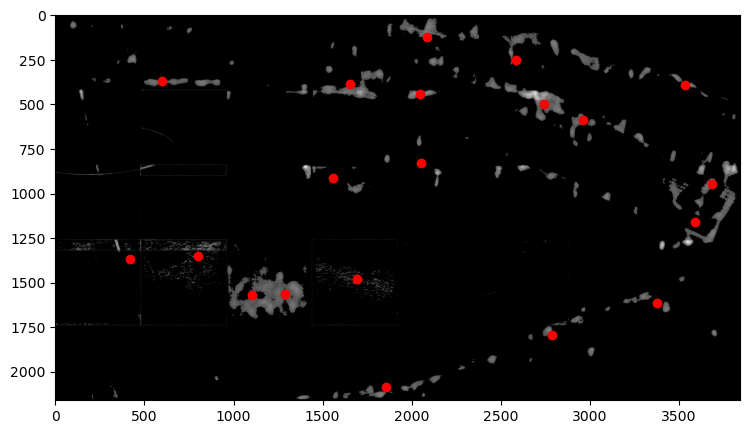

In [ ]:
plt.figure(figsize=(10, 5))

plt.imshow(img[0][0].detach().cpu(), cmap='gray')
plt.scatter(keypoints[:, 1].detach().cpu(), keypoints[:, 0].detach().cpu(), c='red')
plt.show()

plt.figure(figsize=(10, 5))

plt.imshow(clipped_mask_all[0][0].detach().cpu(), cmap='gray')
plt.scatter(keypoints[:, 1].detach().cpu(), keypoints[:, 0].detach().cpu(), c='red')
plt.show()